### one-hot 表达谱相似度计算

ACTG1 与 ACTB 的余弦相似度: 1.0000


/home/xiaoxinyu/miniconda3/envs/redehist/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:501: RuntimeWarning: invalid value encountered in true_divide
  explained_variance_ratio_ = explained_variance_ / total_var


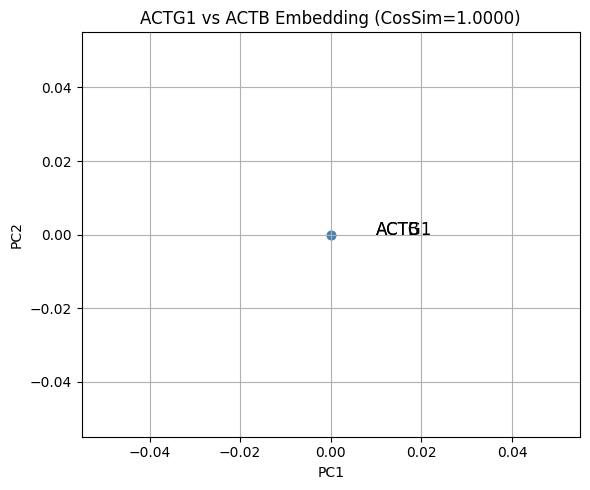

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# 加载 embedding
emb_actg1 = torch.load('/data1/xiaoxinyu/project/gene_text_pairs/gene2go/gene-embeddings/ACTG1_gene.pt')
emb_actb = torch.load('/data1/xiaoxinyu/project/gene_text_pairs/gene2go/gene-embeddings/ACTB_gene.pt')

# 转为 numpy
vec1 = emb_actg1.detach().numpy().reshape(1, -1)
vec2 = emb_actb.detach().numpy().reshape(1, -1)

# 计算余弦相似度
sim = cosine_similarity(vec1, vec2)[0][0]
print(f"ACTG1 与 ACTB 的余弦相似度: {sim:.4f}")

# 可视化：降维 + 标注
X = np.vstack([vec1, vec2])
genes = ['ACTG1', 'ACTB']

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], color='steelblue')
for i, gene in enumerate(genes):
    plt.text(X_pca[i, 0] + 0.01, X_pca[i, 1], gene, fontsize=12)
plt.title(f'ACTG1 vs ACTB Embedding (CosSim={sim:.4f})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.tight_layout()
plt.show()


### 单细胞转录组数据相似度计算

In [ ]:
scdata = sc.read_h5ad("/data1/xiaoxinyu/data/redehist/example_data/sc_data.FFPE.anno.h5ad")

In [ ]:
print(scdata[0, :].obs.head()) # Macrophages (巨噬细胞)
print(scdata[1, :].obs.head()) # T cells (T细胞)
print(scdata[2, :].obs.head()) # Tumor (肿瘤细胞)
print(scdata[3, :].obs.head()) # Stromal (基质细胞)
print(scdata[4, :].obs.head()) # Myoepithelial (肌上皮细胞)
print(scdata[5, :].obs.head()) # DCIS (导管原位癌细胞)
print(scdata[6, :].obs.head()) # Tumor (肿瘤细胞)
print(scdata[7, :].obs.head()) # Macrophages (巨噬细胞)
print(scdata[8, :].obs.head()) # T cells (T细胞)
print(scdata[9, :].obs.head()) # DCIS (导管原位癌细胞)


                     annotation
AAACAAGCAAACGGGA-1  Macrophages
                   annotation
AAACAAGCAAATAGGA-1    T cells
                   annotation
AAACAAGCAAATGACT-1      Tumor
                   annotation
AAACAAGCAACAAGTT-1    Stromal
                       annotation
AAACAAGCAACCATTC-1  Myoepithelial
                   annotation
AAACAAGCAACTAAAC-1       DCIS
                   annotation
AAACAAGCAAGTCGCG-1      Tumor
                     annotation
AAACAAGCAATACCCT-1  Macrophages
                   annotation
AAACAAGCAATGGGAG-1    T cells
                   annotation
AAACAAGCACAAGCGT-1       DCIS


In [7]:
first_row = scdata[2, :].copy()  
first_row.write("/data1/xiaoxinyu/project/1111/sc2.h5ad")

h5ad_path = "/data1/xiaoxinyu/project/1111/sc2.h5ad"
        
gene_out = "/data1/xiaoxinyu/project/1111/sc2.pt"

subprocess.run([
            "conda", "run", "-n", "nicheformer",
            "python", "/data1/xiaoxinyu/project/gene-embedding.py",
            "--input", h5ad_path,
            "--output", gene_out
        ], check=True)

Using provided technology mean array with shape (20310,)
✅ Embedding saved to: /data1/xiaoxinyu/project/1111/sc2.pt



CompletedProcess(args=['conda', 'run', '-n', 'nicheformer', 'python', '/data1/xiaoxinyu/project/gene-embedding.py', '--input', '/data1/xiaoxinyu/project/1111/sc2.h5ad', '--output', '/data1/xiaoxinyu/project/1111/sc2.pt'], returncode=0)

In [11]:
first_row = scdata[3, :].copy()  
first_row.write("/data1/xiaoxinyu/project/1111/sc3.h5ad")

h5ad_path = "/data1/xiaoxinyu/project/1111/sc3.h5ad"
        
gene_out = "/data1/xiaoxinyu/project/1111/sc3.pt"

subprocess.run([
            "conda", "run", "-n", "nicheformer",
            "python", "/data1/xiaoxinyu/project/gene-embedding.py",
            "--input", h5ad_path,
            "--output", gene_out
        ], check=True)

Using provided technology mean array with shape (20310,)
✅ Embedding saved to: /data1/xiaoxinyu/project/1111/sc3.pt



CompletedProcess(args=['conda', 'run', '-n', 'nicheformer', 'python', '/data1/xiaoxinyu/project/gene-embedding.py', '--input', '/data1/xiaoxinyu/project/1111/sc3.h5ad', '--output', '/data1/xiaoxinyu/project/1111/sc3.pt'], returncode=0)

In [8]:
first_row = scdata[6, :].copy()  
first_row.write("/data1/xiaoxinyu/project/1111/sc6.h5ad")

h5ad_path = "/data1/xiaoxinyu/project/1111/sc6.h5ad"
        
gene_out = "/data1/xiaoxinyu/project/1111/sc6.pt"

subprocess.run([
            "conda", "run", "-n", "nicheformer",
            "python", "/data1/xiaoxinyu/project/gene-embedding.py",
            "--input", h5ad_path,
            "--output", gene_out
        ], check=True)

Using provided technology mean array with shape (20310,)
✅ Embedding saved to: /data1/xiaoxinyu/project/1111/sc6.pt



CompletedProcess(args=['conda', 'run', '-n', 'nicheformer', 'python', '/data1/xiaoxinyu/project/gene-embedding.py', '--input', '/data1/xiaoxinyu/project/1111/sc6.h5ad', '--output', '/data1/xiaoxinyu/project/1111/sc6.pt'], returncode=0)

In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# 加载 embedding
emb_actg1 = torch.load('/data1/xiaoxinyu/project/1111/sc2.pt')
emb_actb = torch.load('/data1/xiaoxinyu/project/1111/sc6.pt')

# 转为 numpy
vec1 = emb_actg1.detach().numpy().reshape(1, -1)
vec2 = emb_actb.detach().numpy().reshape(1, -1)

# 计算余弦相似度
sim = cosine_similarity(vec1, vec2)[0][0]
print(f"余弦相似度: {sim:.4f}")


余弦相似度: 0.2689


In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# 加载 embedding
emb_actg1 = torch.load('/data1/xiaoxinyu/project/1111/sc2.pt')
emb_actb = torch.load('/data1/xiaoxinyu/project/1111/sc3.pt')

# 转为 numpy
vec1 = emb_actg1.detach().numpy().reshape(1, -1)
vec2 = emb_actb.detach().numpy().reshape(1, -1)

# 计算余弦相似度
sim = cosine_similarity(vec1, vec2)[0][0]
print(f"余弦相似度: {sim:.4f}")


余弦相似度: 0.7487


### soft-profile 表达谱相似度计算

In [21]:
import anndata

adata = anndata.read_h5ad("/data1/xiaoxinyu/project/gene_text_pairs/gene2go/gene-h5ad_2/HBB.h5ad")
expr = adata.X[0].A1 if hasattr(adata.X[0], 'A1') else adata.X[0]  # CSR matrix -> array
idx = list(adata.var_names).index("HBB")
print(adata)
print(f"HBB表达值: {expr[idx]}")
print(f"表达谱均值: {expr.mean():.2f}，标准差: {expr.std():.2f}")


AnnData object with n_obs × n_vars = 1 × 19335
HBB表达值: 129275.14622981792
表达谱均值: 37.96，标准差: 937.28


In [ ]:
import subprocess

h5ad_path = "/data1/xiaoxinyu/project/gene_text_pairs/gene2go/gene-h5ad_2/HBA1.h5ad"
        
gene_out = "/data1/xiaoxinyu/project/1111/HBA1.pt"  

subprocess.run([
            "conda", "run", "-n", "nicheformer",
            "python", "/data1/xiaoxinyu/project/gene-embedding.py",
            "--input", h5ad_path,
            "--output", gene_out
        ], check=True)

Using provided technology mean array with shape (20310,)
✅ Embedding saved to: /data1/xiaoxinyu/project/1111/HBA1.pt



CompletedProcess(args=['conda', 'run', '-n', 'nicheformer', 'python', '/data1/xiaoxinyu/project/gene-embedding.py', '--input', '/data1/xiaoxinyu/project/gene_text_pairs/gene2go/gene-h5ad_2/HBA1.h5ad', '--output', '/data1/xiaoxinyu/project/1111/HBA1.pt'], returncode=0)

In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# 加载 embedding
emb_actg1 = torch.load('/data1/xiaoxinyu/project/1111/HBA1.pt')
emb_actb = torch.load('/data1/xiaoxinyu/project/1111/HBB.pt')

# 转为 numpy
vec1 = emb_actg1.detach().numpy().reshape(1, -1)
vec2 = emb_actb.detach().numpy().reshape(1, -1)

# 计算余弦相似度
sim = cosine_similarity(vec1, vec2)[0][0]
print(f"余弦相似度: {sim:.4f}")


余弦相似度: 0.9718


### 真实表达谱相似度计算

In [6]:
import anndata
import numpy as np

# 加载原始 h5ad
adata = anndata.read_h5ad("/data1/xiaoxinyu/project/gene_text_pairs/DLPFC/gene-h5ad/spot_4669.h5ad")

# 计算每个基因的总表达量（所有 spot 上求和）
gene_sum = np.array(adata.X.sum(axis=0)).flatten()

# 获取前 20,000 个表达量最大的基因索引
top_k = 20000
top_gene_indices = np.argsort(gene_sum)[-top_k:]

# 筛选这些基因对应的列（axis=1）
adata_top = adata[:, top_gene_indices]

# 保存为新 h5ad（可选）
adata_top.write_h5ad("/data1/xiaoxinyu/project/1111/spot_4669_top20000.h5ad")


In [7]:
import subprocess

h5ad_path = "/data1/xiaoxinyu/project/1111/spot_4669_top20000.h5ad"
        
gene_out = "/data1/xiaoxinyu/project/1111/spot_4669.pt"

subprocess.run([
            "conda", "run", "-n", "nicheformer",
            "python", "/data1/xiaoxinyu/project/gene-embedding.py",
            "--input", h5ad_path,
            "--output", gene_out
        ], check=True)

Using provided technology mean array with shape (20310,)
✅ Embedding saved to: /data1/xiaoxinyu/project/1111/spot_4669.pt



CompletedProcess(args=['conda', 'run', '-n', 'nicheformer', 'python', '/data1/xiaoxinyu/project/gene-embedding.py', '--input', '/data1/xiaoxinyu/project/1111/spot_4669_top20000.h5ad', '--output', '/data1/xiaoxinyu/project/1111/spot_4669.pt'], returncode=0)

In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# 加载 embedding
emb_actg1 = torch.load("/data1/xiaoxinyu/project/1111/spot_4669.pt")
emb_actb = torch.load("/data1/xiaoxinyu/project/1111/spot_0002.pt")

# 转为 numpy
vec1 = emb_actg1.detach().numpy().reshape(1, -1)
vec2 = emb_actb.detach().numpy().reshape(1, -1)

# 计算余弦相似度
sim = cosine_similarity(vec1, vec2)[0][0]
print(f"余弦相似度: {sim:.4f}")


余弦相似度: 0.9736
